# MW/M31 Halo Major Merger Remnant Structure


## Topic: Density Profile of the Merged Dark Matter Remnant

```
Maritza Torres
ASTR 400B
Research Assignment 5
```

**Main Area of Focus**:
Analyzing the density profile/structure of the Dark Matter halo remnant after the two galaxies - Milky Way (MW) and Andromeda (M31) merge together using N-body simulations. My motivation for this project is to analyze the density distribution but also how it might compare to other theoretical analytical models like for example Hernquist and NFW profiles.

**Questions:** 
1. What is the density profile of the combined MW + M31 halo? 
2. How does this compare to the original profile of each galaxy halo? 
3. How does this compare to a Hernquist profile or other dark matter profile (e.g. NFW, Isothermal Sphere)?
4. Where is the edge of the merged halo and how can we define it? Calculate the properties such as R200, Virial Radius (Rvir)

I will need to compute the density profile of the merged MW/M31 dark matter halos before and after merging using N-body simulations which will model the interaction between the two galaxies. Giving me an overall representation of the mass distribution at different time steps. 

**Primary Objective for Overall Assignment:**
- Set up and plot a Hernquist Profile/NFW for the merged Dark Matter halo at snapshot 779 (~11.1 GYR) - final post merger remnant
- Analyze the density distribution of merged remanant -understand the density distribution of the modeled remnant structure. - structure evolves through the merger
- Compare the results with the simulated density profile obtained from the simulation- arrays/calculations vs equations - shape/behavior
- Compare the merged profiles to the original halos separately (000) - the structural evolution of the Dark Matter remanant after such event and density distribution at various radial shells 
- Determine the edge of the Dark Matter halo remnant- get structural properties 
- Ultimately determine how suitable the theoretical models are in producing an accurate representation of the Dark Matter distribution after the major merger. 

**Methodology:**
* Read and upload snapshot 000 and 779 - initial and final merged halo structure
* Obtain and combine all the Dark Matter particles only for MW/M31 - get mass, pos, vel -type 1
* Compute the Center of mass for the merged halo at snapshot 779 - use the pos/mass to get the center
* Get the radial distances of each Dark Matter particle from the COM and bin the distances to determine the density (mass per volume) at different r (radial shells)
* Compare the final combined MW/M31 halo at snapshot 779 to the original profile (snapshot 000) individually
* Make the Hernquist profile and NFW analytically using the equations 
* Plot the profiles to the simulated data for the merged halo in order to compare - N body vs analytically (simulation vs theory) 
* Determine the outer boundary of the merged halo by calculating R200  and Rvir to compute the edge/size - vital for cosmological models like CDM

To begin: Import Python packages

In [92]:
import numpy as np # numpy provides powerful multi-dimensional arrays to hold and manipulate data
import matplotlib.pyplot as plt # matplotlib provides powerful functions for plotting figures
import matplotlib 
import astropy.units as u # astropy provides unit system and constants for astronomical calculations
import astropy.constants as const
from IPython.display import Latex # import Latex module so we can display the results with symbols
from Read1 import Read # import read file function to read the information line by line - created by me 
from CenterOfMass2 import CenterOfMass # homework 4 but implemented my read file

Read and Upload the inital Snapshots (Snapshot 000) for both the Milky Way and M31 which represents the pre-merger structure. Will essentially answer the second question - "How does this compare to the original profile of each galaxy halo?"

In [93]:
time11, number11,data11 = Read('MW_000.txt') # the milky way
time22, number22, data22 = Read('M31_000.txt') # andromeda

Read and upload the snapshots pertaining to after the merge ~11.1 GYR. Snapshot 779

In [94]:
time, number,data = Read('MW_779.txt') # the milky way
time2, number2, data2 = Read('M31_779.txt') # andromeda

Get all the Dark Matter particles only (type 1) from each galaxy:

In [95]:
particle = 1 # particle type is 1 for halos/dark matter
# before the merger
i11 = np.where(data11['type'] == particle) #mw
i22 = np.where(data22['type'] == particle) #m31
# after the merger
i1 = np.where(data['type'] == particle) # #create an array to store indexes of particles of desired Ptype
i2 = np.where(data2['type'] == particle) 

Get the properties for Dark Matter only: 
                  **Mass, Position , Velocity**.          
Use concatenation of arrays to combine the MW/M31 Dark Matter properties together:

In [116]:
# The properties for Mw and M31 before the merge 
x1 = data11['x'][i11] # mw
y1 = data11['y'][i11]
z1 = data11['z'][i11]
m1 = data11['m'][i11] * 1e10*u.Msun
# m31
x2 = data22['x'][i22]  
y2 = data22['y'][i22]
z2 = data22['z'][i22]
m2 = data22['m'][i22] * 1e10*u.Msun

# The properties for MW and M31 combined together -779
# postion
x = np.concatenate((data['x'][i1],data2['x'][i2]))
y = np.concatenate((data['y'][i1],data2['y'][i2]))
z = np.concatenate((data['z'][i1],data2['z'][i2]))
# velocity
vx = np.concatenate((data['vx'][i1],data2['vx'][i2]))
vy = np.concatenate((data['vy'][i1],data2['vy'][i2]))
vz = np.concatenate((data['vz'][i1],data2['vz'][i2]))
# mass
m = np.concatenate((data['m'][i1],data2['m'][i2])) * 1e10*u.Msun 

**From** Homework 4 I will implement COMdefine in order to efficiently compute COM, radial distances, and set up the density profiles. Basically the array for the combined MW/M31.

In [117]:
def COMdefine(a,b,c,m):
    ''' Method to compute the COM of a generic vector quantity by direct weighted averaging.
        
    PARAMETERS
    a : `float or np.ndarray of floats`first vector component
    b : `float or np.ndarray of floats` second vector component
    c : `float or np.ndarray of floats` third vector component
    m : `float or np.ndarray of floats` particle masses
        
    RETURNS
    -------
    a_com : `float` first component on the COM vector
    b_com : `float` second component on the COM vector
    c_com : `float` third component on the COM vector
    ''' 
    a_com = np.sum(a*m)/np.sum(m) # this is the x component of mass
    b_com = np.sum(b*m)/np.sum(m) # this is the y component of mass
    c_com = np.sum(c*m)/np.sum(m) # this is the z component of mass
    return a_com, b_com, c_com # return the components by using commas

In [118]:
# the components combined - after the merge
xm,ym,zm = COMdefine(x,y,z,m)  

**Now** compute the COM (Center of Mass) for the merged Dark halo distribution using Homework 4. In order to shift the positions to ensure its centered correctly.
Reference: GoogleAI for how to properly set up the radial distances and volume of spherical shell

We can do this by getting the radial distances of all particles:

$r = \sqrt{(x-x_{\text{COM}})^2+(y-y_{\text{COM}})^2+(z-z_{\text{COM}})^2}$


In [119]:
# COM for both MW and M31 before the merge for type 1 paricles - Dark Matter
COMW = CenterOfMass('MW_000.txt',1) 
COM31 = CenterOfMass('M31_000.txt',1)
# COM for both MW and M31 after the merge for type 1 paricles - Dark Matter
COMT = np.array([xm,ym,zm]) * u.kpc 

In [120]:
# the position with a tolerance/shrink value as we are using the second version of COM 
COMPOS = COMW.COM_P(delta=0.1, volDec =2)
COM3POS = COM31.COM_P(delta=0.1, volDec =2)

CHANGE =  2.5590215377875003
maxR 2768.338871117187
CHANGE =  3.358773721136014
maxR 1384.1694355585935
CHANGE =  0.9120712521480278
maxR 692.0847177792967
CHANGE =  0.10452805903723883
maxR 346.04235888964837
CHANGE =  0.5154546708720726
maxR 173.02117944482418
CHANGE =  0.6367077202381308
maxR 86.51058972241209
CHANGE =  0.19943347671078038
maxR 43.255294861206046
CHANGE =  0.6032901523521192
maxR 21.627647430603023
CHANGE =  0.4639983012206623
maxR 10.813823715301512
CHANGE =  0.18568150044640097
maxR 5.406911857650756
CHANGE =  0.39801621157617895
maxR 2.703455928825378
CHANGE =  0.2597755552273182
maxR 1.351727964412689
CHANGE =  0.022597624660816606
maxR 0.6758639822063445
CHANGE =  1.3055086221243073
maxR 2765.3582265281602
CHANGE =  1.2018856188011569
maxR 1382.6791132640801
CHANGE =  1.152577327299241
maxR 691.3395566320401
CHANGE =  0.9224389220593139
maxR 345.66977831602003
CHANGE =  1.3454474603954623
maxR 172.83488915801001
CHANGE =  0.44293256638889034
maxR 86.41744457900

In [121]:
# now we have the particles sort of recenter by shifting x,y,z
#before
xnew = COMW.x *u.kpc - COMPOS[0] # mw
ynew= COMW.y *u.kpc - COMPOS[1]
znew= COMW.z *u.kpc - COMPOS[2]
# m31
xnew1 = COM31.x *u.kpc - COM3POS[0] 
ynew1= COM31.y *u.kpc - COM3POS[1]
znew1= COM31.z *u.kpc - COM3POS[2]
#after
xnew2= x *u.kpc - COMT[0]
ynew2= y *u.kpc - COMT[1]
znew2= z *u.kpc - COMT[2]

In [122]:
# use the radial distance equation to compute the distance from the center
rMW = np.sqrt((xnew)**2 + (ynew)**2 + (znew)**2)  # radius particle's vector
print("Before MW:",r) # used to help compute the bin particles
r31 = np.sqrt((xnew1)**2 + (ynew1)**2 + (znew1)**2)   
print("Before M31:",r)  
rM = np.sqrt((xnew2)**2 + (ynew2)**2 + (znew2)**2)   # shift the combined particles
print("After :",r)  

Before MW: [ 296.3980195   688.34745183 1275.06005439 ...  138.84967516  198.31186972
  579.72335328] kpc
Before M31: [ 296.3980195   688.34745183 1275.06005439 ...  138.84967516  198.31186972
  579.72335328] kpc
After : [ 296.3980195   688.34745183 1275.06005439 ...  138.84967516  198.31186972
  579.72335328] kpc


Compute the bin particles using radial distances:

In [156]:
#create radial bins
binsx = np.logspace(np.log10(0.1),np.log10(500),50) *u.kpc
#calculate the center of the bin
centerbin = 0.5*(binsx[:-1]+binsx[1:])
# volume of a spherical shell to compute the radial shells - density distribution
vol = (4/3)* np.pi*(binsx[1:]**3-binsx[:-1]**3)

**Set** up the density profiles using histogram with the bins:     
Reference: Lab7

In [157]:
# MW inital
MPMW,_ = np.histogram(rMW,bins=binsx, weights=m1, density=False)
#mass density enclosed calculation
density = MPMW/vol
#M31 inital 
MP31,_ = np.histogram(r31,bins=binsx, weights=m2, density=False)
#mass density
density31 = MP31/vol
#MW and M31 combined
MW31M,_ = np.histogram(rM,bins=binsx, weights=m, density=False)
#mass density
densityM = MW31M/vol

**Plot** the density profile of the combined MW + M31 halo and then overlay the original profile of each galaxy halo:

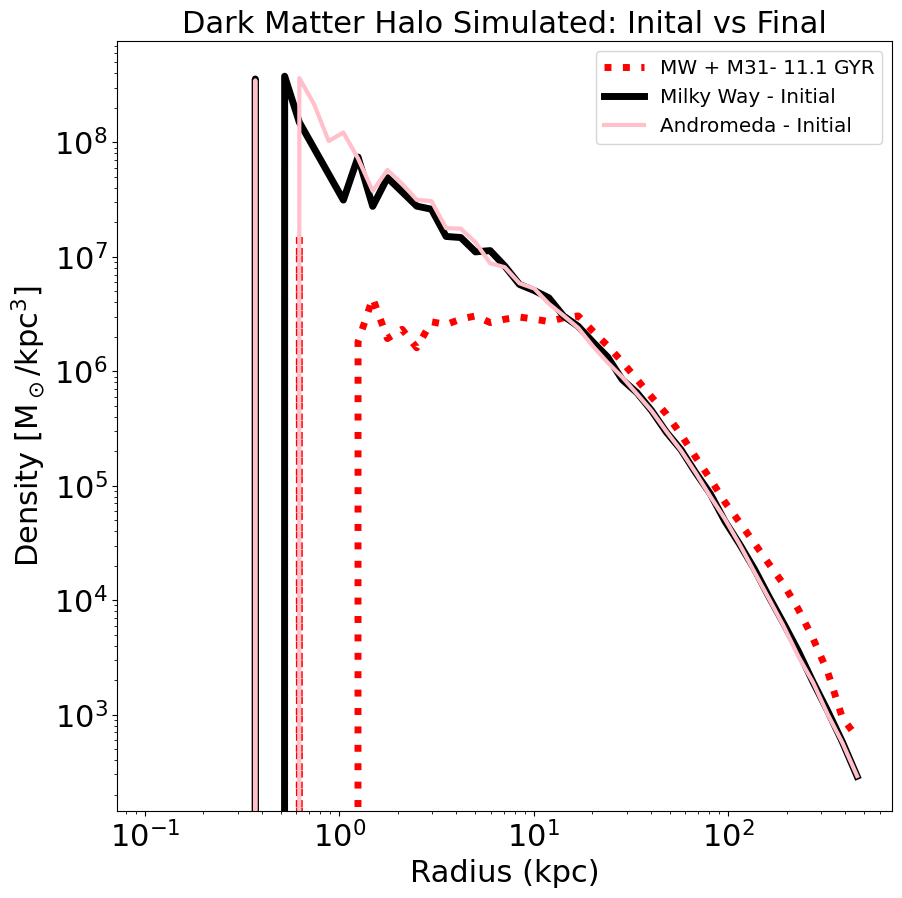

In [158]:
# code for the plot 
fig = plt.figure(figsize=(10,10))  # sets the scale of the figure
ax = plt.subplot(111) 
ax.loglog(centerbin,densityM, color='red', linewidth=5,linestyle='dotted', label='MW + M31- 11.1 GYR')
ax.loglog(centerbin,density, color='black', linewidth=5, label='Milky Way - Initial')
ax.loglog(centerbin,density31, color='pink', linewidth=3, label='Andromeda - Initial')
# Add labels
plt.xlabel("Radius (kpc)", fontsize=22)
plt.ylabel("Density [M$_\\odot$/kpc$^3$]", fontsize=22)
plt.title("Dark Matter Halo Simulated: Inital vs Final",fontsize=22)
#adjust tick label font size
label_size = 22

# add a legend  
legend = ax.legend(loc='upper right',fontsize='x-large')

plt.show() # show the plot

Lets make a Hernquist function so its easier to plot:

Hernquist Profile:

$\rho(r) =  \frac{M_{halo}}{2\pi} \frac{a}{r(r+a)^3} \qquad  $ 

In [128]:
def Hernquist(r, Mhalo, a):
    """ This function will compute the density for radii within, using the theoretical profile.  
        Inputs: r: `(kpc) this is the distance from the center  
        a: (kpc) the radius length  of the mass density's movement
        Mhalo: (solar mass) the total mass of the halo 
        Returns: HernDens:  the density distribution 
    """ 
    x = ((Mhalo*u.Msun) /(2*np.pi)) # first part of the equation and make conversions
    y = ((a*u.kpc) / ((r*u.kpc)*(r*u.kpc + a*u.kpc )**3)) # the second part of the equation
    HernDens = x*y # we now multiple both equations 
    return HernDens  # this is the hernquist density profile in solar mass units

Lets make the Navarro-Frenk-White (NFW) density profile function
(The Astrophysical Journal, Volume 490, Issue 2, pp. 493-508.)

$\rho(r) =  \frac{\rho_0}{\left( \frac{r}{a2} \right)\left( 1 + \frac{r}{a2} \right)^2}  $ 

In [129]:
def NFW(r, rho, a2):
    """ This function will compute the spherically averaged density of Dark Matter halos 
        Inputs: r: `(kpc) this is the distance from the center of the Dark Matter halo to the measuring density  
        a: (kpc) the scale radius 
        rho: (solar mass) inital density 
        Returns: NFWDens:  the density distribution 
    """ 
    x1 = (rho*u.Msun/u.kpc**3) # first part of the equation and make conversions
    y2 = (r*u.kpc)/(a2*u.kpc) # the second part of the equation
    z = ((1 + (r*u.kpc)/(a2*u.kpc))**2) # the addition to the second part
    x3 = (y2) * z # take the two bottom parts together
    NFWDens = x1/x3 # we now divide both equations 
    return NFWDens  # this is the Navarro-Frank density profile in solar mass units

**Plot** the Hernquist profile and NFW profile:

In [174]:
# use center
binsy = np.logspace(0.1,3,100)  
#calculate the center of the bin
centerbins = 0.5*(binsy[:-1]+binsy[1:])

In [177]:
# set up the parameters for both density profiles
Mhalo = np.sum(m)
Hernquist_Profile = Hernquist(centerbins,Mhalo,28)
rho = np.max(densityM)
NFW_Profile = NFW(centerbins,rho,27)

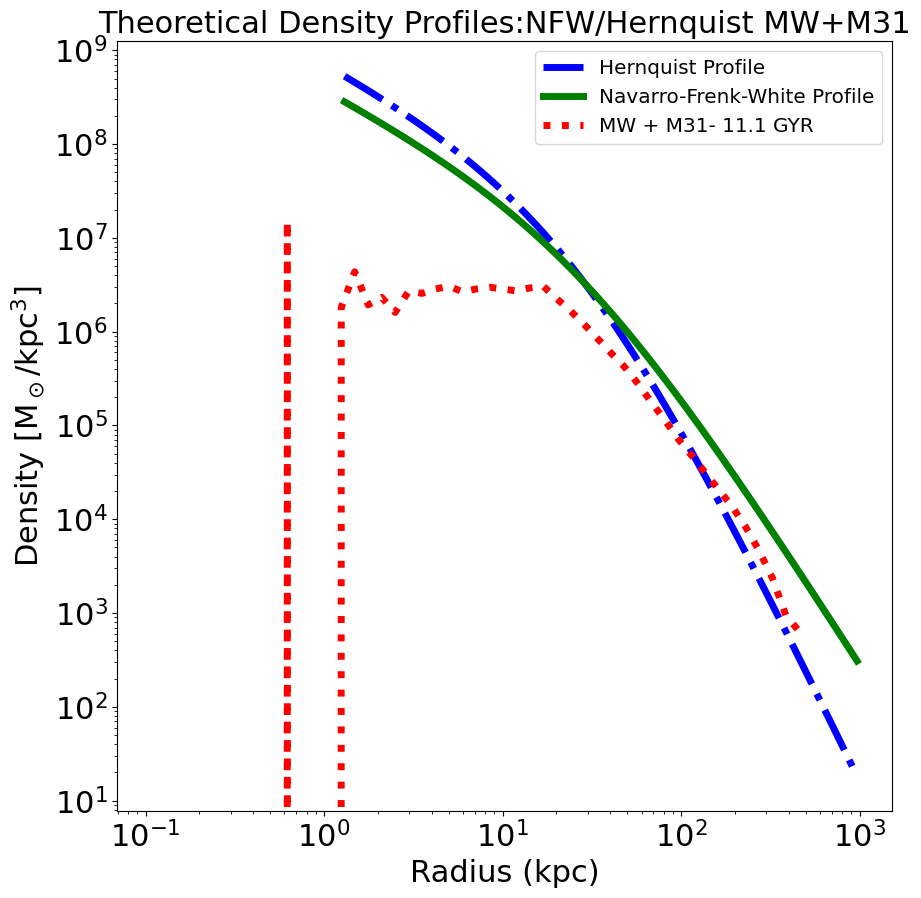

In [182]:
# code for the plot 
fig = plt.figure(figsize=(10,10))  # sets the scale of the figure
ax = plt.subplot(111) 
# Plot the  best fit hernquist profile
ax.loglog(centerbins, Hernquist_Profile, color='blue', linewidth=5,linestyle='dashdot', label='Hernquist Profile')
ax.loglog(centerbins, NFW_Profile, color='green', linewidth=5,linestyle='solid', label='Navarro-Frenk-White Profile')
# Add labels
plt.xlabel("Radius (kpc)", fontsize=22)
plt.ylabel("Density [M$_\\odot$/kpc$^3$]", fontsize=22)
plt.title("Theoretical Density Profiles:NFW/Hernquist MW+M31",fontsize=22)
#adjust tick label font size
label_size = 22
matplotlib.rcParams['xtick.labelsize'] = label_size 
matplotlib.rcParams['ytick.labelsize'] = label_size
# add a legend  
legend = ax.legend(loc='upper right',fontsize='x-large')

plt.show() # show the plot

**Overall**, The first plot reveals how Dark Matter behaves during major galactic mergers. The inner regions seems to be more effected by the merger while outer regions remains stable. The structure remains the same in the outer regions while the inner seem to be heavily effected by mass redistribution. At larger radii it remains it seems to hold its structure.
The Hernquist profile/NFW aids in understanding how the structure of a Dark Matter halo evolves throughout the merger. They both show a similar structure but the hernquist seems to end quicker with a larger radii. But the NFW has a higher density- denser outer halo. Both profiles present qualitative knowledge on how Dark Matter is distributed when a major merger occurs. Unlocking the true nature of Dark Matter as a whole but also the overall structure of the Dark Matter halo remnant following a Major merger.

**Lastly** computing the outer edges of the halo in order to uncover more information about the boundaries of the said merged Dark Matter remant but also allowing the opportunity to explore the behavior of Dark Matter as a whole.

R200 
I need to calculate the radius where the  dark matter density is 200x the critical density(pcrit) needed to close the universe 
Virial Radius (Rvir)
Dark matter density is  360x the average dark matter density of the universe.  
Splash back radius
outer boundary where particles reach apocenter of their first orbit.
Rvir > R200


In [179]:
RvirMW = 260 * u.kpc
# compute the pcrit at redshift which is z=0
# the radial distances used for COM will be adjusted
# get the enclosed mass dependent on radius
# then ultimately get the radius which the average is 200 times the pcrit
# plot density vs radius